In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
pio.renderers.default = "png"
import pandas as pd
import plotly.express as px
import textwrap

import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config, radar_plot_x_stats

In [2]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [3]:
data.season.unique()

<StringArray>
['2022-23', '2023-24', '2024-25', '2025-26']
Length: 4, dtype: string

In [4]:
data.head()

,name,position,xP,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_expected_points,opp_expected_points,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
0,Nathan Redmond,MID,1.5,0,0,3,0,0.0,403,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2022-08-06T14:00:00Z,1,18,0,0,0,0,0,5871.0,0,0,1,0,0,0,5.5,False,0,1,83283,2022-23,2022-08-06,1,4,-3,790,0.0,0.000000,0.000000,0.0,0.0,3.0,0.4576,2.3215,1.0,4.0,0.386546,1.617200,0.386546,1.617200,-1.230654,1.230654,15.545455,5.700000,7.0,12.0,-1.230654,9.845455,790.0
1,Junior Stanislas,MID,1.1,0,0,3,0,0.0,58,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2022-08-06T14:00:00Z,1,2,0,0,0,0,0,9491.0,0,0,1,0,0,0,5.0,True,0,1,56872,2022-23,2022-08-06,2,0,2,463,0.0,0.000000,0.000000,0.0,3.0,0.0,1.4036,1.1567,2.0,0.0,0.588341,0.488895,0.588341,0.488895,0.099446,-0.099446,11.680000,6.608696,3.0,11.0,0.099446,5.071304,463.0
2,Armando Broja,FWD,2.0,0,0,3,0,0.3,150,0.0,0.0,0.0,0.0,0,0,2.5,5.2,2022-08-06T16:30:00Z,15,8,0,0,0,0,0,124903.0,0,19,1,0,0,0,5.5,False,0,1,440323,2022-23,2022-08-06,1,0,1,8384,1.0,0.000000,0.000000,0.0,3.0,0.0,2.4766,0.3517,1.0,0.0,1.923150,0.541983,1.161980,0.541983,0.619997,-0.619997,6.192308,12.000000,7.0,3.0,0.619997,-5.807692,8384.0
3,Fabian Schär,DEF,2.4,0,3,43,1,14.6,366,0.0,0.0,0.0,0.0,0,1,10.6,66.0,2022-08-06T14:00:00Z,90,16,0,0,0,0,0,40132.0,0,25,15,0,0,0,4.5,True,0,1,119471,2022-23,2022-08-06,2,0,2,76,2.0,0.606013,0.606013,1.0,3.0,0.0,2.5764,0.2541,2.0,0.0,1.859100,0.235825,1.859100,0.235825,1.623275,-1.623275,6.080000,13.333333,24.0,2.0,1.623275,-7.253333,76.0
4,Jonny Evans,DEF,1.9,0,0,15,0,1.3,249,0.0,0.0,0.0,0.0,2,0,1.5,14.0,2022-08-07T13:00:00Z,90,4,0,0,0,0,0,24256.0,0,0,1,0,0,0,4.5,True,0,1,37642,2022-23,2022-08-07,2,2,0,807,0.0,0.136849,0.136849,0.0,1.0,1.0,0.8336,1.8173,2.0,2.0,0.455695,0.931067,0.455695,0.931067,-0.475372,0.475372,17.705882,22.214286,5.0,3.0,-0.475372,-4.508403,807.0


In [5]:
data.rename(columns={
    "expected_goals_conceded" : "xg_conceded",
    "expected_goals" : "xg",
    "expected_goal_involvements" : "xg_involvements",
    "team_expected_points" : "team_xp",
    "opp_expected_points" : "opp_xp",
    "expected_assists" : "xa"
}, inplace=True)

In [6]:
data.shape

(106178, 66)

In [7]:
data.season.unique()

<StringArray>
['2022-23', '2023-24', '2024-25', '2025-26']
Length: 4, dtype: string

In [24]:
data.season = data.season.str.replace("20", "").str.replace("-", "").astype(int)

In [25]:
data = data.loc[data.position != "AM", :]

In [26]:
data = sort_data(data)
data.head()

,name,position,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_xp,opp_xp,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
0,Andy Lonergan,GK,1.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-22T14:00:00Z,0,7,0,0,0,0,0,0.0,0,0,0,0,0,0,4.0,False,0,32,11948,2223,2023-04-22,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.0,0.0,0.433712,0.368137,0.433712,0.368137,0.065575,-0.065575,8.818182,9.437500,3.0,5.0,0.065575,-0.619318,0.0
1,Andy Lonergan,GK,-0.5,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-04-27T18:45:00Z,0,15,0,0,0,0,0,33.0,0,0,0,17,18,1,4.0,True,0,33,11948,2223,2023-04-27,1,4,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,0.1780,2.7298,1.0,4.0,0.777008,2.863680,0.777008,2.863680,-2.086672,2.086672,11.363636,9.000000,6.0,9.0,-2.086672,2.363636,0.0
2,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-01T19:00:00Z,0,10,0,0,0,0,0,84.0,0,0,0,19,25,6,4.0,False,0,34,11948,2223,2023-05-01,2,2,0,0,0.0,0.0,0.0,0.0,1.0,1.0,1.3268,1.4183,2.0,2.0,3.286480,3.324860,2.525310,2.563690,-0.038380,0.038380,8.692308,7.523810,9.0,5.0,-0.038380,1.168498,0.0
3,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-08T16:30:00Z,0,5,0,0,0,0,0,111.0,0,0,0,11,32,21,4.0,False,0,35,11948,2223,2023-05-08,5,1,4,0,0.0,0.0,0.0,0.0,3.0,0.0,1.2187,1.5493,5.0,1.0,2.942230,3.237170,2.942230,3.237170,-0.294940,0.294940,17.050000,3.058824,10.0,16.0,-0.294940,13.991176,0.0
4,Andy Lonergan,GK,0.0,0,0,0,0,0.0,760,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2023-05-14T13:00:00Z,0,13,0,0,0,0,0,134.0,0,0,0,-3,22,25,4.0,True,0,36,11948,2223,2023-05-14,0,3,-3,0,0.0,0.0,0.0,0.0,0.0,3.0,1.4578,1.1956,0.0,3.0,1.185970,1.043380,1.185970,1.043380,0.142590,-0.142590,25.400000,17.153846,1.0,9.0,0.142590,8.246154,0.0


In [27]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,gw,code,season,date,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_xp,opp_xp,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,understat
count,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.0,105856.000000,105856,105856.000000,105856.000000,105856.000000,105856.0,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.00000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000,105856.000000
mean,0.96223,0.034981,0.086126,4.803129,0.075763,4.04512,373.37431,0.022802,0.05836,0.036296,0.395772,0.441827,0.038628,1.387292,6.014675,26.633889,10.497327,0.00154,0.000595,0.000463,0.001663,0.081734,225761.77134,0.269139,3.824063,1.139425,1096.211041,15365.538666,14269.260958,4.89535,0.052893,19.552553,298412.353584,2367.378401,2024-06-10 15:50:51.783555072,1.481626,1.501417,-0.019791,2873.683702,0.349947,0.122991,0.074575,0.260080,1.379090,1.40455,1.392500,1.412370,1.494294,1.513216,1.581002,1.595240,1.482861,1.496995,-0.003699,0.031223,12.997709,12.917022,7.410378,7.496552,-0.003699,0.165369,2873.683702
min,-3.0,0.0,0.0,-25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,-2993262.0,0.0,0.0,3.6,0.0,1.0,11948.0,2223.000000,2022-08-05 00:00:00,0.000000,0.000000,-9.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.001700,0.001700,0.000000,0.000000,0.020346,0.020346,0.020346,0.020346,-5.715141,-5.715141,2.303030,2.303030,0.000000,0.000000,-5.715141,-187.058824,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,185.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4237.0,0.0,0.0,0.0,-1039.0,19.0,90.0,4.3,0.0,11.0,158534.0,2223.000000,2023-05-28 00:00:00,1.000000,1.000000,-1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.657200,0.673400,1.000000,1.000000,0.885512,0.893899,0.817578,0.830779,-0.872727,-0.849981,8.357143,8.363636,4.000000,4.000000,-0.872727,-5.591652,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,18771.5,0.0,0.0,0.0,-59.0,262.0,706.0,4.5,0.0,20.0,225796.0,2324.000000,2024-04-27 00:00:00,1.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,1.342050,1.370200,1.000000,1.000000,1.417500,1.424200,1.326040,1.338360,-0.002560,0.030034,11.473684,11.454545,7.000000,7.000000,-0.002560,0.082237,0.000000
75%,1.4,0.0,0.0,6.0,0.0,1.5,555.0,0.01,0.01,0.0,0.54,0.0,0.0,1.9,7.2,70.0,15.0,0.0,0.0,0.0,0.0,0.0,113463.75,1.0,2.0,1.0,20.0,3206.25,5792.5,5.1,0.0,28.0,476344.0,2425.000000,2025-04-20 00:00:00,2.000000,2.000000,1.000000,6665.0,0.000000,0.081703,0.022847,0.000000,3.000000,3.00000,2.102000,2.124800,2.000000,2.000000,2.120100,2.156680,1.984610,2.010180,0.870862,0.910900,15.478261,15.428571,10.000000,10.000000,0.870862,5.825000,6665.000000
max,24.8,4.0,3.0,102.0,1.0,135.1,866.0,1.47,3.88,3.67,9.84,9.0,4.0,32.6,149.0,90.0,20.0,2.0,2.0,2.0,1.0,13.0,9582624.0,1.0,169.0,26.0,1674116.0,1689375.0,3024167.0,15.4,1.0,38.0,704232.0,2526.000000,2026-03-05 00:00:00,9.000000,9.000000,9.000000,14410.0,12.000000,3.640940,2.886233,9.000000,3.000000,3.0000

In [28]:
data.shape

(105856, 66)

Text(0, 0.5, 'Liczba graczy')

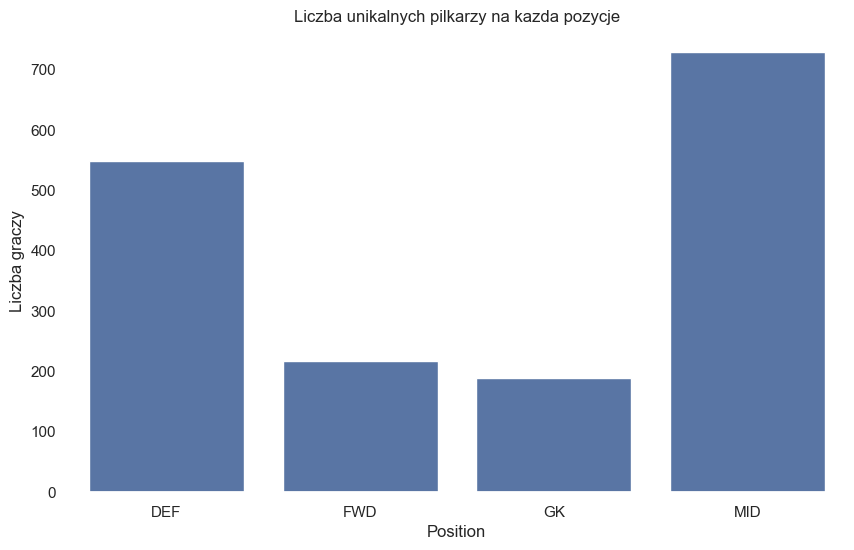

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position")["name"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [30]:
[c for c in data.columns if "points" in c]

['total_points', 'team_points', 'opp_points']

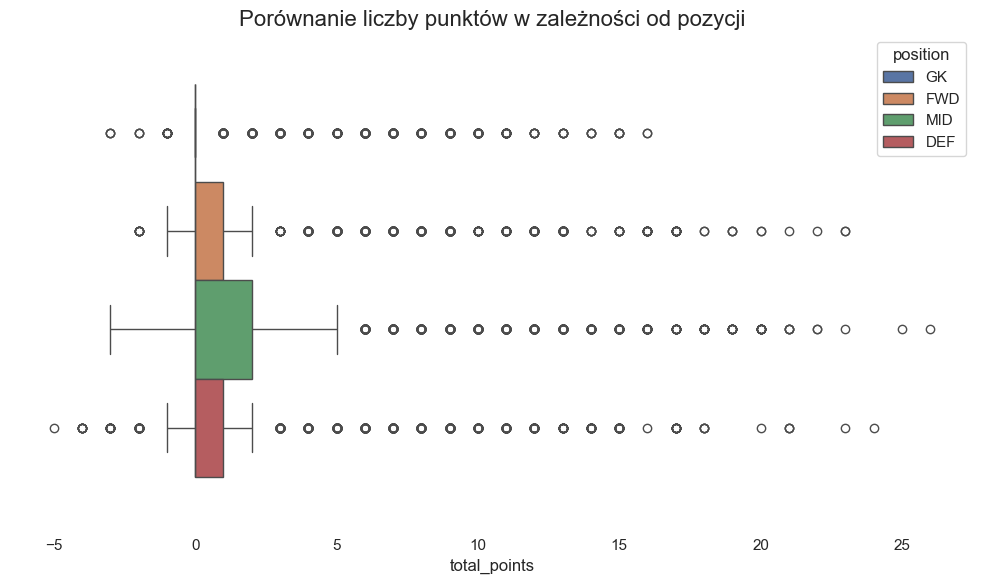

In [31]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Total Points')

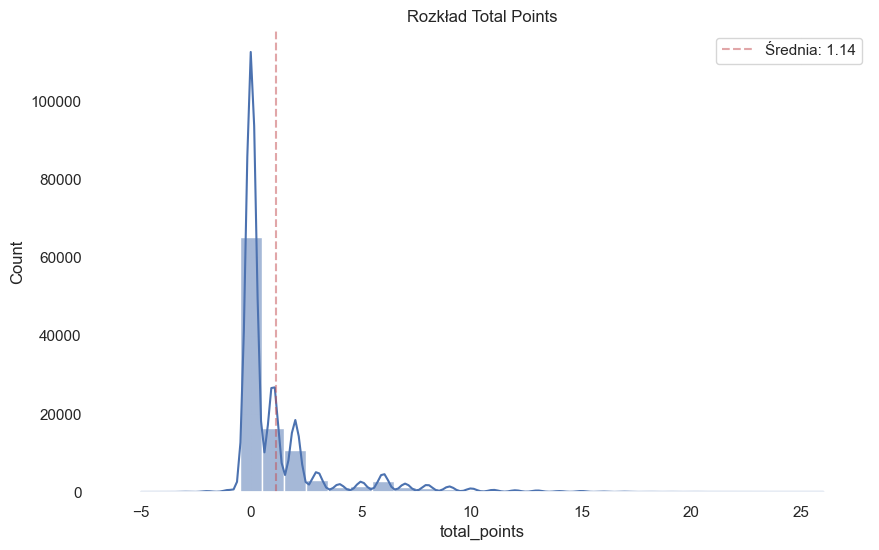

In [32]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.total_points,
             kde=True,
            #palette="magma",
             discrete=True,
             bins=30)
ax.axvline(data.total_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.total_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Total Points")

<Axes: >

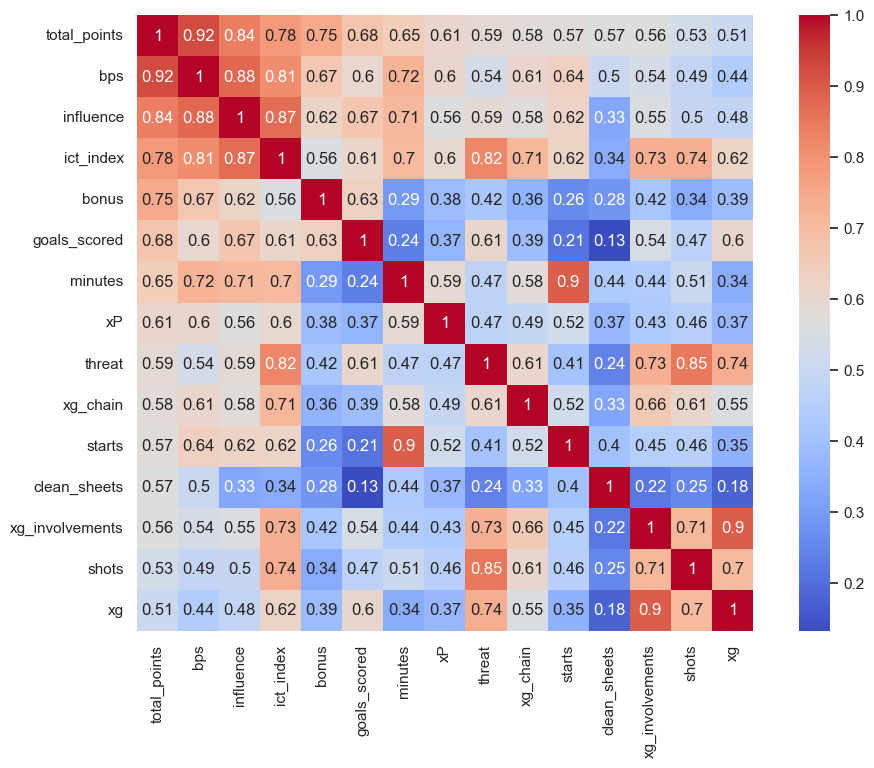

In [33]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

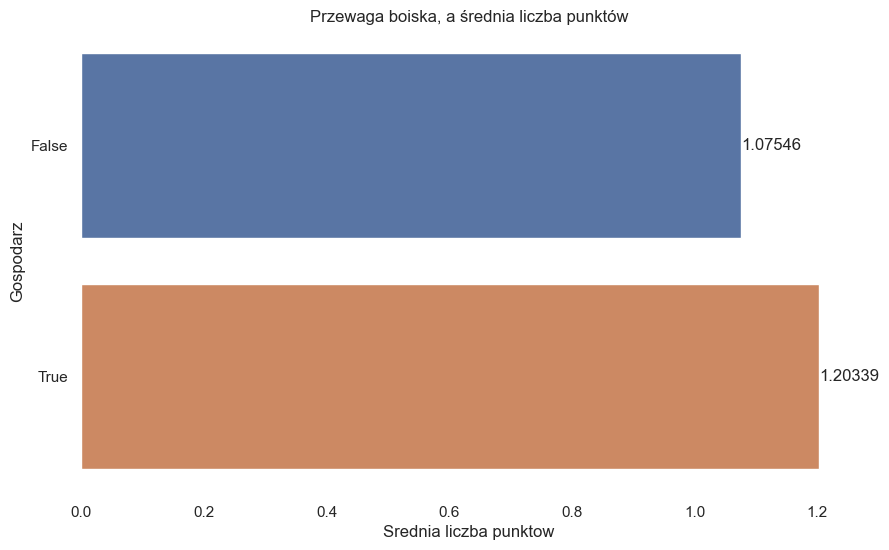

In [34]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [35]:
data.season.unique()

array([2223, 2324, 2425, 2526])

In [36]:
data[data.season==2526].gw.unique()

<IntegerArray>
[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Length: 29, dtype: Int64

In [37]:
[c for c in data.columns if "sele" in c]

['selected']

In [38]:
data.position.unique()

<StringArray>
['GK', 'FWD', 'MID', 'DEF']
Length: 4, dtype: string

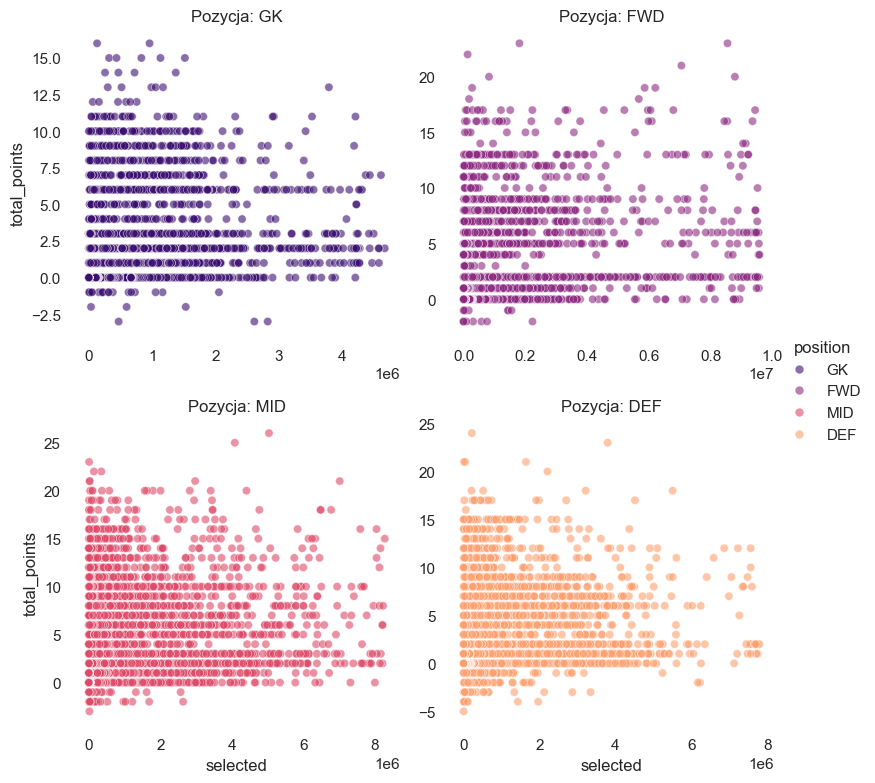

In [39]:
g = sns.relplot(
    data=data,
    x="selected",
    y="total_points",
    col="position",
    hue="position",
    col_wrap=2,
    palette="magma",
    kind="scatter",
    alpha=0.6,
    height=4,
    facet_kws={'sharex': False, 'sharey': False}

)

g.set_titles("Pozycja: {col_name}")

plt.show()

In [40]:
team_x_stats = [c for c in data.columns if "x" in c and c!="ict_index" and ("team" in c or "opp" in c)]
player_x_stasts = [c for c in data.columns if "x" in c and c!="ict_index" and c not in team_x_stats and c !="xP"]

player_x_stasts

['xa', 'xg_involvements', 'xg', 'xg_conceded', 'xg_chain', 'xg_buildup']

In [41]:
data.position.unique()

<StringArray>
['GK', 'FWD', 'MID', 'DEF']
Length: 4, dtype: string

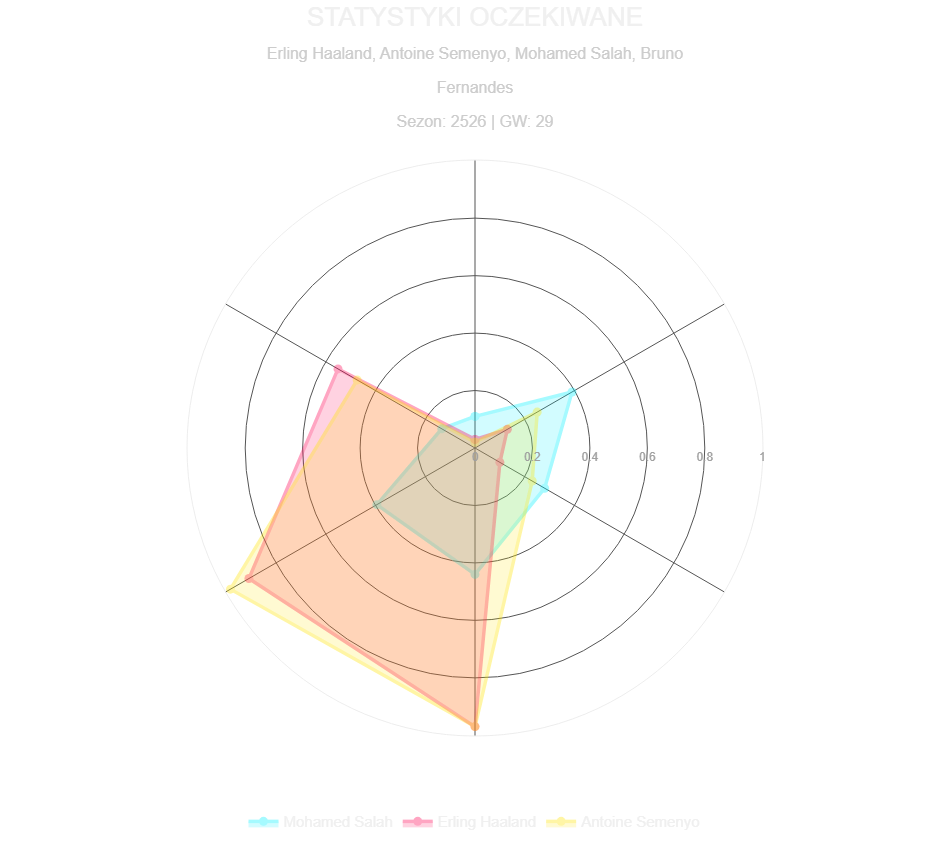

In [42]:
radar_plot_x_stats(df=data,
                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],
                   stats=player_x_stasts)

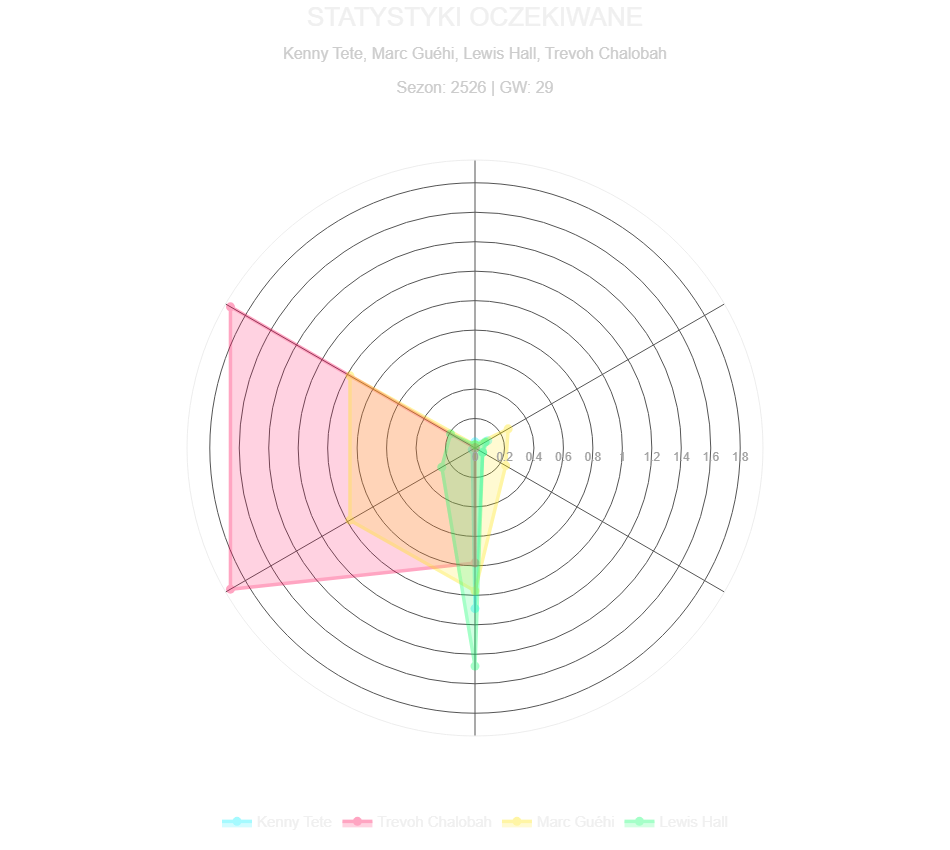

In [43]:
radar_plot_x_stats(df=data,
                   players=['Kenny Tete', "Marc Guéhi", "Lewis Hall",  'Trevoh Chalobah'],
                   stats=player_x_stasts)

In [44]:
data.to_parquet(config.TIDY_DATA_PATH)